In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
dataset = pd.read_csv('../data/cleveland_clean.csv')
dataset.head()

,Umur,Jenis_Kelamin,Tipe_Nyeri_Dada,Tekanan_Darah,Kolesterol,Gula_Darah_Puasa,EKG_Istirahat,Detak_Jantung_Max,Angina_Olahraga,Depresi_ST,Kemiringan_ST,Jumlah_Pembuluh_Utama,Thalassemia,Target_Label,oldpeak_minmax,oldpeak_standard
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,A,0.370968,1.087338
1,37,1,3,130,250,0,0,187,0,3.5,3,0,3,A,0.564516,2.122573
2,41,0,2,130,204,0,2,172,0,1.4,1,0,3,A,0.225806,0.310912
3,56,1,2,120,236,0,0,178,0,0.8,1,0,3,A,0.129032,-0.206705
4,57,0,4,120,354,0,0,163,1,0.6,1,0,3,A,0.096774,-0.379244


In [ ]:
# ==========================================
# 2. PREPROCESSING TARGET 
# ==========================================
dataset['Target_Encoded'] = dataset['Target_Label'].apply(lambda x: 0 if x == 'A' else 1)

print("\n--- Distribusi Target (0=Sehat, 1=Sakit) ---")
print(dataset['Target_Encoded'].value_counts())


--- Distribusi Target (0=Sehat, 1=Sakit) ---
Target_Encoded
0    164
1    139
Name: count, dtype: int64


In [14]:
# ==========================================
# 3. NORMALISASI FITUR (MINMAX SCALER)
# ==========================================
X = dataset.drop(['Target_Label', 'Target_Encoded'], axis=1)
y = dataset['Target_Encoded']

# Inisialisasi Scaler
scaler = MinMaxScaler()

# Lakukan Scaling
X_scaled = scaler.fit_transform(X)

# Kembalikan ke DataFrame (Otomatis pakai nama kolom: Umur, Kolesterol, dll)
X_scaled_dataset = pd.DataFrame(X_scaled, columns=X.columns)

# === OUTPUT YANG DIMINTA ===
# Cara menampilkan tabel cantik di Jupyter
from IPython.display import display

print("\n--- Output: 5 Data Teratas Setelah Normalisasi ---")
display(X_scaled_dataset.head())

print("\n--- Output: Statistik Normalisasi (Cek Min=0 & Max=1) ---")
display(X_scaled_dataset.describe().loc[['min', 'max']])


--- Output: 5 Data Teratas Setelah Normalisasi ---


,Umur,Jenis_Kelamin,Tipe_Nyeri_Dada,Tekanan_Darah,Kolesterol,Gula_Darah_Puasa,EKG_Istirahat,Detak_Jantung_Max,Angina_Olahraga,Depresi_ST,Kemiringan_ST,Jumlah_Pembuluh_Utama,Thalassemia,oldpeak_minmax,oldpeak_standard
0,0.708333,1.0,0.000000,0.481132,0.244292,1.0,1.0,0.603053,0.0,0.370968,1.0,0.0,0.75,0.370968,0.370968
1,0.166667,1.0,0.666667,0.339623,0.283105,0.0,0.0,0.885496,0.0,0.564516,1.0,0.0,0.00,0.564516,0.564516
2,0.250000,0.0,0.333333,0.339623,0.178082,0.0,1.0,0.770992,0.0,0.225806,0.0,0.0,0.00,0.225806,0.225806
3,0.562500,1.0,0.333333,0.245283,0.251142,0.0,0.0,0.816794,0.0,0.129032,0.0,0.0,0.00,0.129032,0.129032
4,0.583333,0.0,1.000000,0.245283,0.520548,0.0,0.0,0.702290,1.0,0.096774,0.0,0.0,0.00,0.096774,0.096774



--- Output: Statistik Normalisasi (Cek Min=0 & Max=1) ---


,Umur,Jenis_Kelamin,Tipe_Nyeri_Dada,Tekanan_Darah,Kolesterol,Gula_Darah_Puasa,EKG_Istirahat,Detak_Jantung_Max,Angina_Olahraga,Depresi_ST,Kemiringan_ST,Jumlah_Pembuluh_Utama,Thalassemia,oldpeak_minmax,oldpeak_standard
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


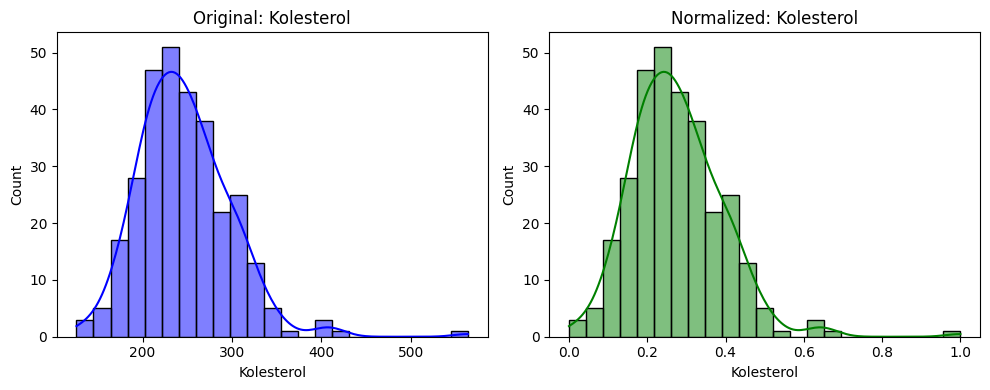

In [5]:
# ==========================================
# 4. VISUALISASI HASIL (VALIDASI)
# ==========================================
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(dataset['Kolesterol'], kde=True, color='blue') 
plt.title('Original: Kolesterol')

plt.subplot(1, 2, 2)
sns.histplot(X_scaled_dataset['Kolesterol'], kde=True, color='green')
plt.title('Normalized: Kolesterol')
plt.tight_layout()
plt.show()


[1] Feature Relevance (Urutan Kepentingan Fitur):
Thalassemia              0.528962
Jumlah_Pembuluh_Utama    0.464167
Angina_Olahraga          0.431894
oldpeak_standard         0.424510
Depresi_ST               0.424510
oldpeak_minmax           0.424510
Detak_Jantung_Max        0.417167
Tipe_Nyeri_Dada          0.414446
Kemiringan_ST            0.339213
Jenis_Kelamin            0.276816
Umur                     0.223120
EKG_Istirahat            0.169202
Tekanan_Darah            0.150825
Kolesterol               0.085164
Gula_Darah_Puasa         0.025264
Name: Target_Encoded, dtype: float64


C:\Users\harto\AppData\Local\Temp\ipykernel_13204\2514385738.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=relevance.values, y=relevance.index, palette='coolwarm')


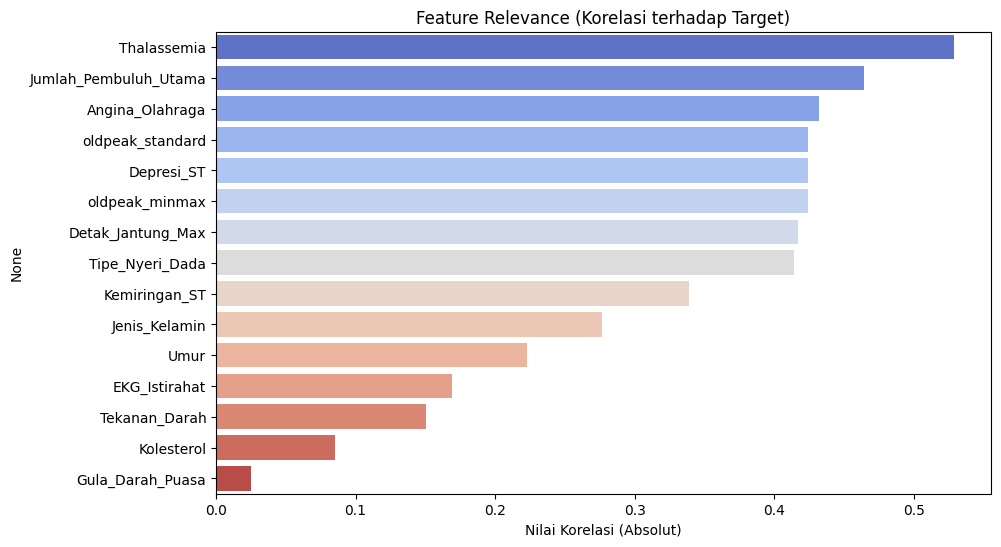

In [6]:
df_analysis = pd.concat([X_scaled_dataset, y], axis=1)

# A. FEATURE RELEVANCE (Korelasi Fitur vs Target)
# ------------------------------------------------
# Kita ingin tahu fitur mana yang paling 'nyambung' dengan penyakit jantung
correlation_matrix = df_analysis.corr()
target_corr = correlation_matrix['Target_Encoded'].drop('Target_Encoded')

# Urutkan dari korelasi tertinggi (Positif/Negatif sama pentingnya)
relevance = target_corr.abs().sort_values(ascending=False)

print("\n[1] Feature Relevance (Urutan Kepentingan Fitur):")
print(relevance)

# Visualisasi Relevance
plt.figure(figsize=(10, 6))
sns.barplot(x=relevance.values, y=relevance.index, palette='coolwarm')
plt.title('Feature Relevance (Korelasi terhadap Target)')
plt.xlabel('Nilai Korelasi (Absolut)')
plt.show()

In [12]:
# ==========================================
# 6A. FEATURE SELECTION: HAPUS FITUR TIDAK RELEVAN
# ==========================================
# 1. Gabungkan sementara X dan y untuk hitung korelasi
df_analysis = pd.concat([X_scaled_dataset, y], axis=1)

# 2. Hitung korelasi terhadap Target
correlation_matrix = df_analysis.corr()
# Ambil nilai korelasi target, dan ambil nilai absolutnya (biar negatif tetap dihitung kuat)
target_corr = correlation_matrix['Target_Encoded'].drop('Target_Encoded').abs()

# 3. Tentukan Batas Minimal (Threshold)
# Angka 0.05 adalah standar umum. Di bawah ini dianggap tidak ada hubungan.
threshold_relevance = 0.05 

# 4. Cari fitur yang nilainya di bawah threshold
irrelevant_features = target_corr[target_corr < threshold_relevance].index.tolist()

print(f"Batas Relevansi (Threshold): {threshold_relevance}")
print("Analisis Relevansi Fitur:")
print(target_corr.sort_values())

# 5. Eksekusi Penghapusan
if len(irrelevant_features) > 0:
    print(f"\nDITEMUKAN FITUR LEMAH (< {threshold_relevance}):")
    print(f"   -> {irrelevant_features}")
    
    # Hapus dari dataset utama
    X_scaled_dataset = X_scaled_dataset.drop(columns=irrelevant_features)
    print("Fitur tersebut BERHASIL DIHAPUS otomatis.")
else:
    print("\nSemua fitur cukup relevan (Tidak ada yang dihapus).")

print(f"\nSisa Fitur ({len(X_scaled_dataset.columns)}):")
print(X_scaled_dataset.columns.tolist())

Batas Relevansi (Threshold): 0.05
Analisis Relevansi Fitur:
Kolesterol               0.085164
Tekanan_Darah            0.150825
EKG_Istirahat            0.169202
Umur                     0.223120
Jenis_Kelamin            0.276816
Kemiringan_ST            0.339213
Tipe_Nyeri_Dada          0.414446
Detak_Jantung_Max        0.417167
Depresi_ST               0.424510
Angina_Olahraga          0.431894
Jumlah_Pembuluh_Utama    0.464167
Thalassemia              0.528962
Name: Target_Encoded, dtype: float64

Semua fitur cukup relevan (Tidak ada yang dihapus).

Sisa Fitur (12):
['Umur', 'Jenis_Kelamin', 'Tipe_Nyeri_Dada', 'Tekanan_Darah', 'Kolesterol', 'EKG_Istirahat', 'Detak_Jantung_Max', 'Angina_Olahraga', 'Depresi_ST', 'Kemiringan_ST', 'Jumlah_Pembuluh_Utama', 'Thalassemia']


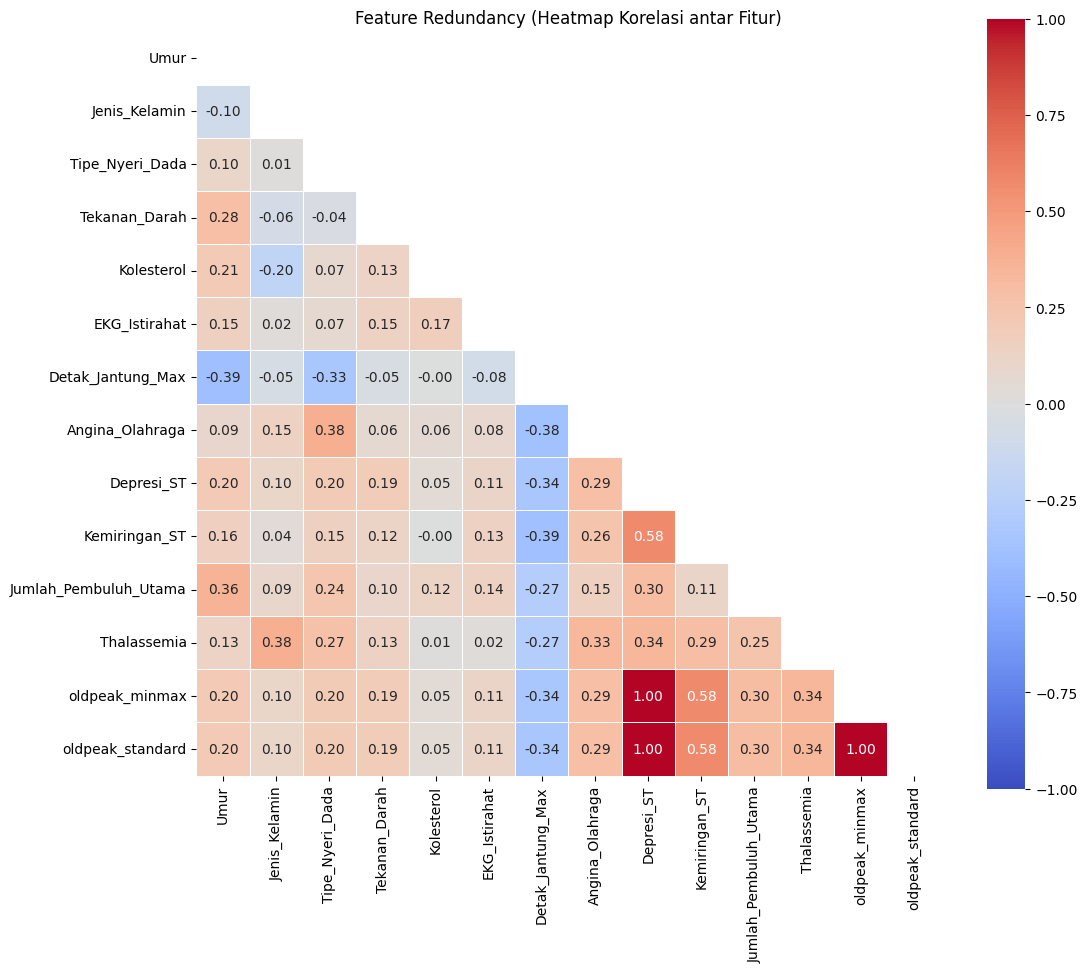


[2] Deteksi Redundansi (Threshold > 0.8):
DITEMUKAN FITUR REDUNDAN (Saran: Buang salah satu):
- Depresi_ST <--> oldpeak_minmax (Korelasi: 1.00)
 Cek Feature Relevance sebelumnya: Pilih yang skornya lebih tinggi, buang yang rendah.
- Depresi_ST <--> oldpeak_standard (Korelasi: 1.00)
 Cek Feature Relevance sebelumnya: Pilih yang skornya lebih tinggi, buang yang rendah.
- oldpeak_minmax <--> oldpeak_standard (Korelasi: 1.00)
 Cek Feature Relevance sebelumnya: Pilih yang skornya lebih tinggi, buang yang rendah.


In [9]:
# ==========================================
# 6B. FEATURE REDUNDANCY (Cek Fitur Kembar)
# ==========================================
# 1. Visualisasi Heatmap (
plt.figure(figsize=(12, 10))

# Buat mask untuk menutupi bagian atas segitiga
mask = np.triu(np.ones_like(X_scaled_dataset.corr(), dtype=bool))

sns.heatmap(X_scaled_dataset.corr(), 
            mask=mask,             # Tutup segitiga atas
            annot=True,            # Tampilkan angka
            fmt=".2f",             # 2 angka desimal
            cmap='coolwarm',       # Merah-Biru
            vmin=-1, vmax=1,       # Batas warna
            square=True, 
            linewidths=.5)

plt.title('Feature Redundancy (Heatmap Korelasi antar Fitur)')
plt.show()

# 2. Cek Otomatis Pasangan Redundan 
threshold_redundancy = 0.8
print(f"\n[2] Deteksi Redundansi (Threshold > {threshold_redundancy}):")

redundant_pairs = []
features = X_scaled_dataset.columns
corr_matrix = X_scaled_dataset.corr().abs()

for i in range(len(features)):
    for j in range(i+1, len(features)):
        if corr_matrix.iloc[i, j] > threshold_redundancy:
            pair = (features[i], features[j], corr_matrix.iloc[i, j])
            redundant_pairs.append(pair)

# 3. Keputusan
if len(redundant_pairs) > 0:
    print("DITEMUKAN FITUR REDUNDAN (Saran: Buang salah satu):")
    for f1, f2, score in redundant_pairs:
        print(f"- {f1} <--> {f2} (Korelasi: {score:.2f})")
        print(f" Cek Feature Relevance sebelumnya: Pilih yang skornya lebih tinggi, buang yang rendah.")
else:
    print("AMAN. Tidak ditemukan fitur yang saling duplikat (redundant).")

In [13]:
# ==========================================
# PEMBERSIHAN KHUSUS: MEMBUANG KOLOM DUPLIKAT
# ==========================================
# Berdasarkan hasil cek redundansi, ditemukan kolom sisa eksperimen
# Kita hanya pertahankan 'Depresi_ST' 

cols_to_drop = ['oldpeak_minmax', 'oldpeak_standard']

# Cek apakah kolom tersebut ada, lalu hapus
# errors='ignore' biar tidak error kalau kolomnya sudah hilang
X_scaled_dataset = X_scaled_dataset.drop(columns=cols_to_drop, errors='ignore')

print(f"Kolom duplikat {cols_to_drop} berhasil dibuang.")
print("Sisa Kolom:", X_scaled_dataset.columns.tolist())

Kolom duplikat ['oldpeak_minmax', 'oldpeak_standard'] berhasil dibuang.
Sisa Kolom: ['Umur', 'Jenis_Kelamin', 'Tipe_Nyeri_Dada', 'Tekanan_Darah', 'Kolesterol', 'EKG_Istirahat', 'Detak_Jantung_Max', 'Angina_Olahraga', 'Depresi_ST', 'Kemiringan_ST', 'Jumlah_Pembuluh_Utama', 'Thalassemia']


In [11]:
# ==========================================
# 7. SIMPAN DATA FINAL (EXPORT)
# ==========================================
dataset_final = pd.concat([X_scaled_dataset, y], axis=1)
output_path = '../data/cleveland_normalized.csv'
dataset_final.to_csv(output_path, index=False)


print(f"SUKSES! File berhasil disimpan ke: {output_path}")
print(f"Dimensi Akhir: {dataset_final.shape} (Baris, Kolom)")
print("Daftar Kolom Final:")
print(dataset_final.columns.tolist())

SUKSES! File berhasil disimpan ke: ../data/cleveland_normalized.csv
Dimensi Akhir: (303, 13) (Baris, Kolom)
Daftar Kolom Final:
['Umur', 'Jenis_Kelamin', 'Tipe_Nyeri_Dada', 'Tekanan_Darah', 'Kolesterol', 'EKG_Istirahat', 'Detak_Jantung_Max', 'Angina_Olahraga', 'Depresi_ST', 'Kemiringan_ST', 'Jumlah_Pembuluh_Utama', 'Thalassemia', 'Target_Encoded']
